In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os, glob
import pandas as pd
from pathlib import Path
from collections import namedtuple
import matplotlib.cm as cm

plt.rcParams['text.usetex'] = False

entry = namedtuple('entry', ['y', 'e'])
stats = namedtuple('Statistics', ['x', 'all_recovery_rate', 'entropy_recovered', 'entropy_stable', 'entropy_unstable', 'entropy_fail'])

In [2]:
def get_col(file, col_name='recovery_rate', percentage=True):
    df = pd.read_csv(file, usecols=[col_name], header=0, engine="pyarrow")
    y = df[col_name].mean()
    err = df[col_name].std(ddof=0) #/ (len(df[col_name]) ** 0.5)
    
    if percentage:
        y, err = map(lambda z: z * 100, (y, err))
    return y, err

def get_stats(files, sample_type, t=0.05, percentage=True):
    try:
        files.sort(key = lambda f: float(Path(f).name.split('=')[1].split('-')[0]))
    except:
        files.sort(key = lambda f: float(Path(f).name))
        
    assert len(files) > 0
    
    file_stats = stats([], [], [], [], [], [])
    for f in files:    
        try:
            csv_file = glob.glob(os.path.join(f, f'stability_t={t}_*_{sample_type}.csv'))[0] 
            rate, rate_err = get_col(csv_file, 'is_exact_match', percentage)

            stb, stb_err = get_col(csv_file, 'entropy_stable', False)
            unstb, unstb_err = get_col(csv_file, 'entropy_unstable', False)
            
            rec, rec_err = get_col(csv_file, 'entropy_recovered', False)
            fail, fail_err = get_col(csv_file, 'entropy_failed_rec', False)
            
        except:
            print(f, sample_type)
            continue 

        x = float(Path(f).name)        
        file_stats.x.append(x)
        
        file_stats.all_recovery_rate.append(entry(rate, rate_err))
        file_stats.entropy_recovered.append(entry(rec, rec_err))
        file_stats.entropy_fail.append(entry(fail, fail_err))

        file_stats.entropy_stable.append(entry(stb, stb_err))
        file_stats.entropy_unstable.append(entry(unstb, unstb_err))
            
    return file_stats

In [27]:
size = 'medium'

files = glob.glob(f"../experiments/stability_greedy/lm1b-wrap-{size}/*")
ts = [1.0]

train_stats = [get_stats(files, 'train', t) for t in ts]
print()
test_stats = [get_stats(files, 'test', t) for t in ts]
print()
rand_stats = [get_stats(files, 'random', t) for t in ts]

x_axis = [data.x for data in train_stats]
train_data = [[item.y for item in data.all_recovery_rate] for data in train_stats]
train_data_err = [[item.e for item in data.all_recovery_rate] for data in train_stats]

test_data = [[item.y for item in data.all_recovery_rate] for data in test_stats]
test_data_err = [[item.e for item in data.all_recovery_rate] for data in test_stats]

rand_data = [[item.y for item in data.all_recovery_rate] for data in rand_stats]
rand_data_err = [[item.e for item in data.all_recovery_rate] for data in rand_stats]

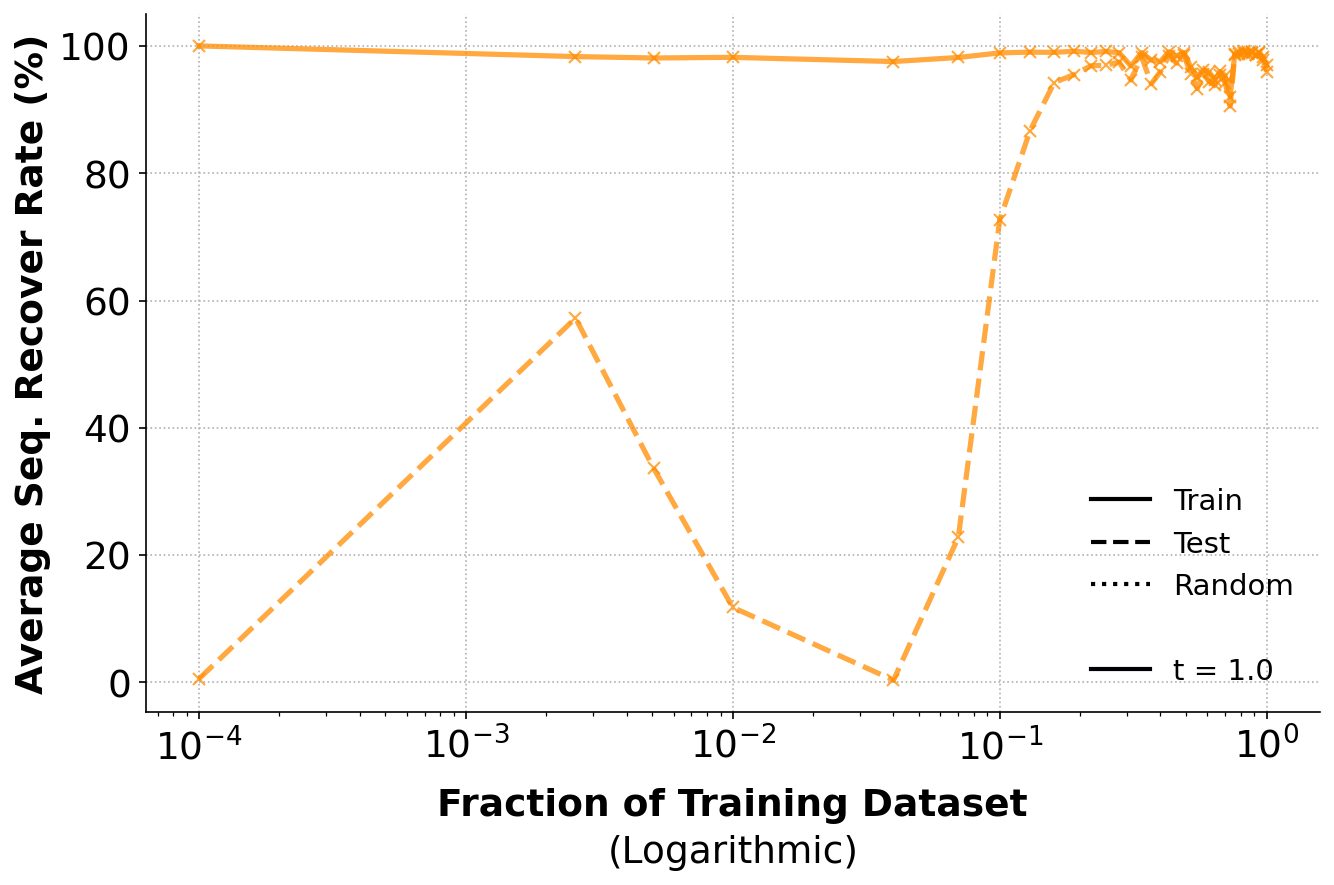

In [29]:
# Setup
fig, ax = plt.subplots(figsize=(9, 6), dpi=150)

fontsize = 18

# Colors: Create a distinct color for each 't'
# Using 'viridis' or 'plasma' ensures perceptually uniform difference
t_values = [1.0]


#colors = cm.viridis(np.linspace(0, 0.9, len(t_values)))
#colors = cm.inferno(np.linspace(0, 0.9, len(t_values)))
#colors = cm.rainbow(np.linspace(0, 0.9, len(t_values)))

skip = [False]

for i, _ in enumerate(t_values):
    if skip[i]: continue
        
    c = 'darkorange'
    
    # Plot Train (Solid)
    ax.plot(x_axis[i], train_data[i], marker='x', label=f't={t_values[i]}' if i==0 else "", 
            color=c, linestyle='-', linewidth=2.5, alpha=0.75)
    
    # Plot Test (Dashed)
    ax.plot(x_axis[i], test_data[i], label=None, marker='x', 
            color=c, linestyle='--', linewidth=2.5, alpha=0.75)

    
    #ax.plot(x_axis[i], rand_data[i], label=None, 
    #        color=c, linestyle=':', linewidth=2.5, alpha=0.75)
    
    #if t_values[i] == 0.50:
    #    ax.fill_between(x_axis[i], train_data[i], test_data[i], color=c, alpha=0.1)

# Custom Legend Construction
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', lw=2, linestyle='-', label='Train'),
    Line2D([0], [0], color='black', lw=2, linestyle='--', label='Test'),
    Line2D([0], [0], color='black', lw=2, linestyle=':', label='Random'),
    Line2D([0], [0], color='white', label=' '), # Spacer
]
# Add color entries for t
for i, t in enumerate(t_values):
    if skip[i]: continue
    legend_elements.append(Line2D([0], [0], color=colors[i], lw=2, label=f't = {t}'))

#if size == 'small':
ax.legend(handles=legend_elements, loc='best', frameon=False, fontsize=14)

# Aesthetics
ax.set_xscale('log')
ax.set_xlabel('Fraction of Training Dataset', fontsize=fontsize, weight='bold', labelpad=10)
ax.set_ylabel('Average Seq. Recover Rate (%)', fontsize=fontsize, weight='bold')

#ax.grid(True, which="both", ls=":", alpha=0.4)
ax.grid(True, which='major', ls=':')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(0.5, -0.175, '(Logarithmic)', transform=ax.transAxes, 
        fontsize=fontsize, weight='normal', ha='center', va='top')

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)

plt.tight_layout()
plt.show()

In [5]:
entropy_stats = namedtuple('Statistics', ['x', 'entropy_recovered', 'entropy_stable', 'entropy_unstable', 'entropy_fail'])

def get_npz(files, sample_type, t=0.05, percentage=True):
    assert len(files) > 0
    files.sort(key = lambda f: float(Path(f).name))
            
    file_stats = entropy_stats([], [], [], [], [])
    for f in files:    
        try:
            npz_file = glob.glob(os.path.join(f, f'stability_t={t}_*_{sample_type}.npz'))[0]
            
            #"entropy", "mask_perturbed", "mask_correct", "mask_unstable"
            arr = np.load(npz_file)
            entropy = arr['entropy']
            
            mask_correct = arr['mask_correct'].astype(bool)
            mask_unstable = arr['mask_unstable'].astype(bool)
            mask_perturbed = arr['mask_perturbed'].astype(bool)
            ent_recovered = entropy[mask_perturbed & mask_correct]
            ent_stable = entropy[~mask_perturbed & mask_correct]
            ent_unstable = entropy[mask_unstable]
            
            #print(ent_unstable)
            #ent_unstable = None

            #print(entropy.shape)
            ent_fail = entropy[np.logical_not(mask_correct)]
                        
        except:
            print(f, sample_type)
            continue 

        x = float(Path(f).name)
        file_stats.x.append(x)
        file_stats.entropy_recovered.append(ent_recovered)
        file_stats.entropy_stable.append(ent_stable)
        file_stats.entropy_unstable.append(ent_unstable)
        file_stats.entropy_fail.append(ent_fail)
    return file_stats

In [6]:
npz_stats = [get_npz(files, 'train', t=t) for t in [0.05, 0.1, 0.25, 0.5, 1.0]]

ent_unstable = [data.entropy_unstable for data in npz_stats]
ent_stable = [data.entropy_stable for data in npz_stats]

ent_fail = [data.entropy_fail for data in npz_stats]
ent_recovered = [data.entropy_recovered for data in npz_stats]

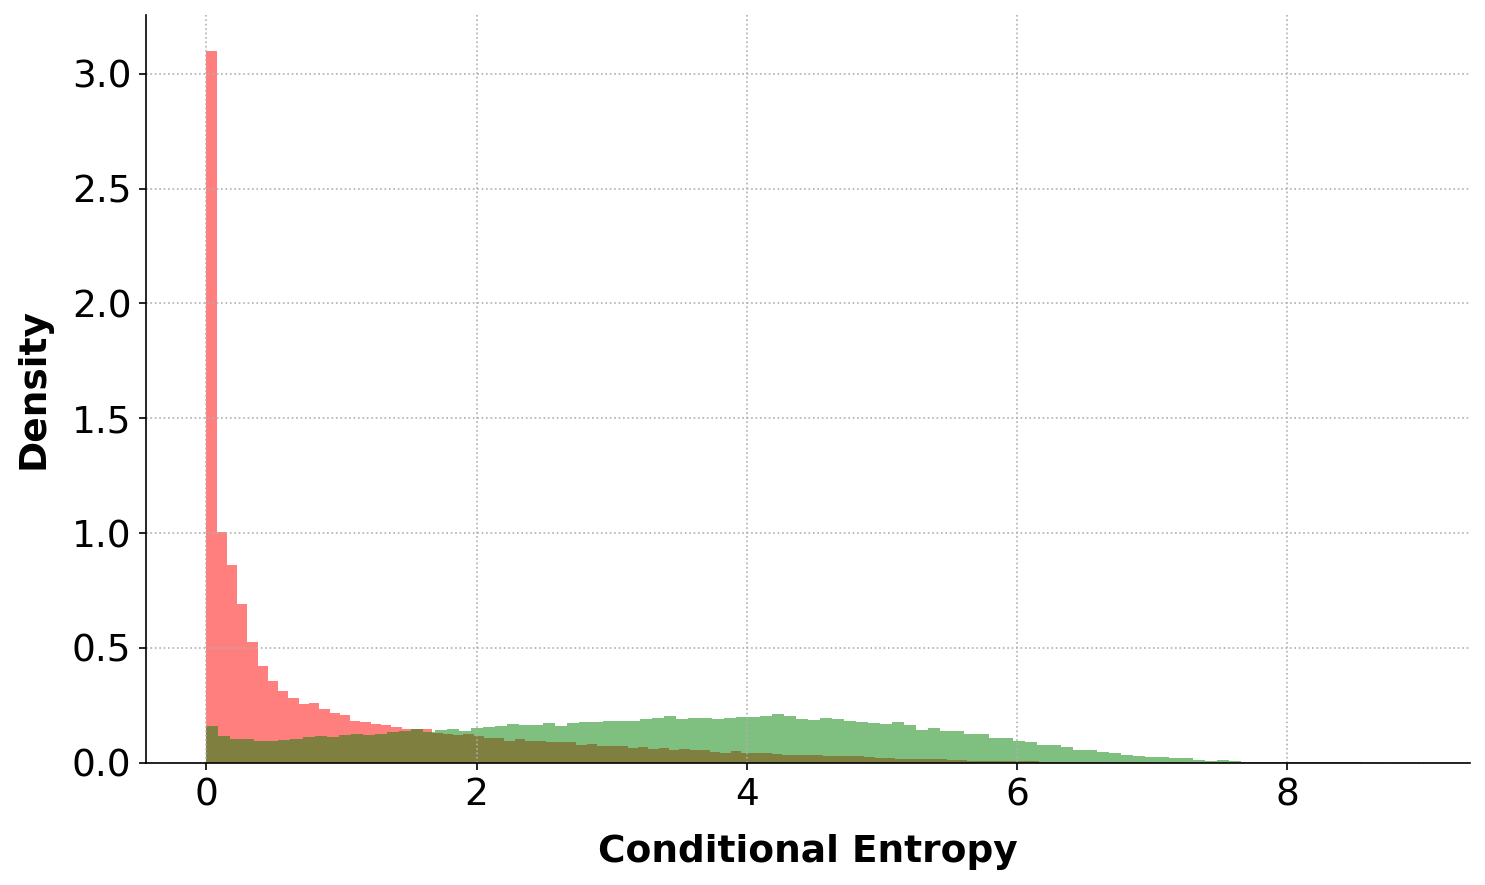

In [7]:
num_bins = 100
density = True

for i, t in enumerate([0.05, 0.1, 0.25, 0.5, 1.0]):
    if i != 2: continue
        
    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)    
    #plt.title(f't = {t}', fontsize=14)
    plt.hist(ent_recovered[i][-1], color='Red', label='Recovered Token', bins=num_bins, density=density, alpha=0.5,)
    plt.hist(ent_fail[i][-1], color='green', label='Unrecovered Token', bins=num_bins, density=density, alpha=0.5,)
    ax.set_xlabel('Conditional Entropy', fontsize=fontsize, weight='bold', labelpad=10)
    ax.set_ylabel('Count' if not density else 'Density', fontsize=fontsize, weight='bold', labelpad=10)
    ax.grid(True, which='major', ls=':')
    
    if i == 0:
        legend_elements = [
            #Line2D([0], [0], color='Blue', lw=5, alpha=0.5, label='Unstable Token'),
            Line2D([0], [0], color='Red', lw=5, alpha=0.5, label='Recovered Token'),
            Line2D([0], [0], color='Green', lw=5, label='Unrecovered Token'), # Spacer
        ]
        #ax.legend(handles=legend_elements, loc='best', frameon=False, fontsize=10)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)

    plt.tight_layout()
    plt.show()

/gpfs/u/home/HPDM/HPDMphmb/scratch/miniconda3x86/lib/python3.9/site-packages/numpy/lib/histograms.py:883: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


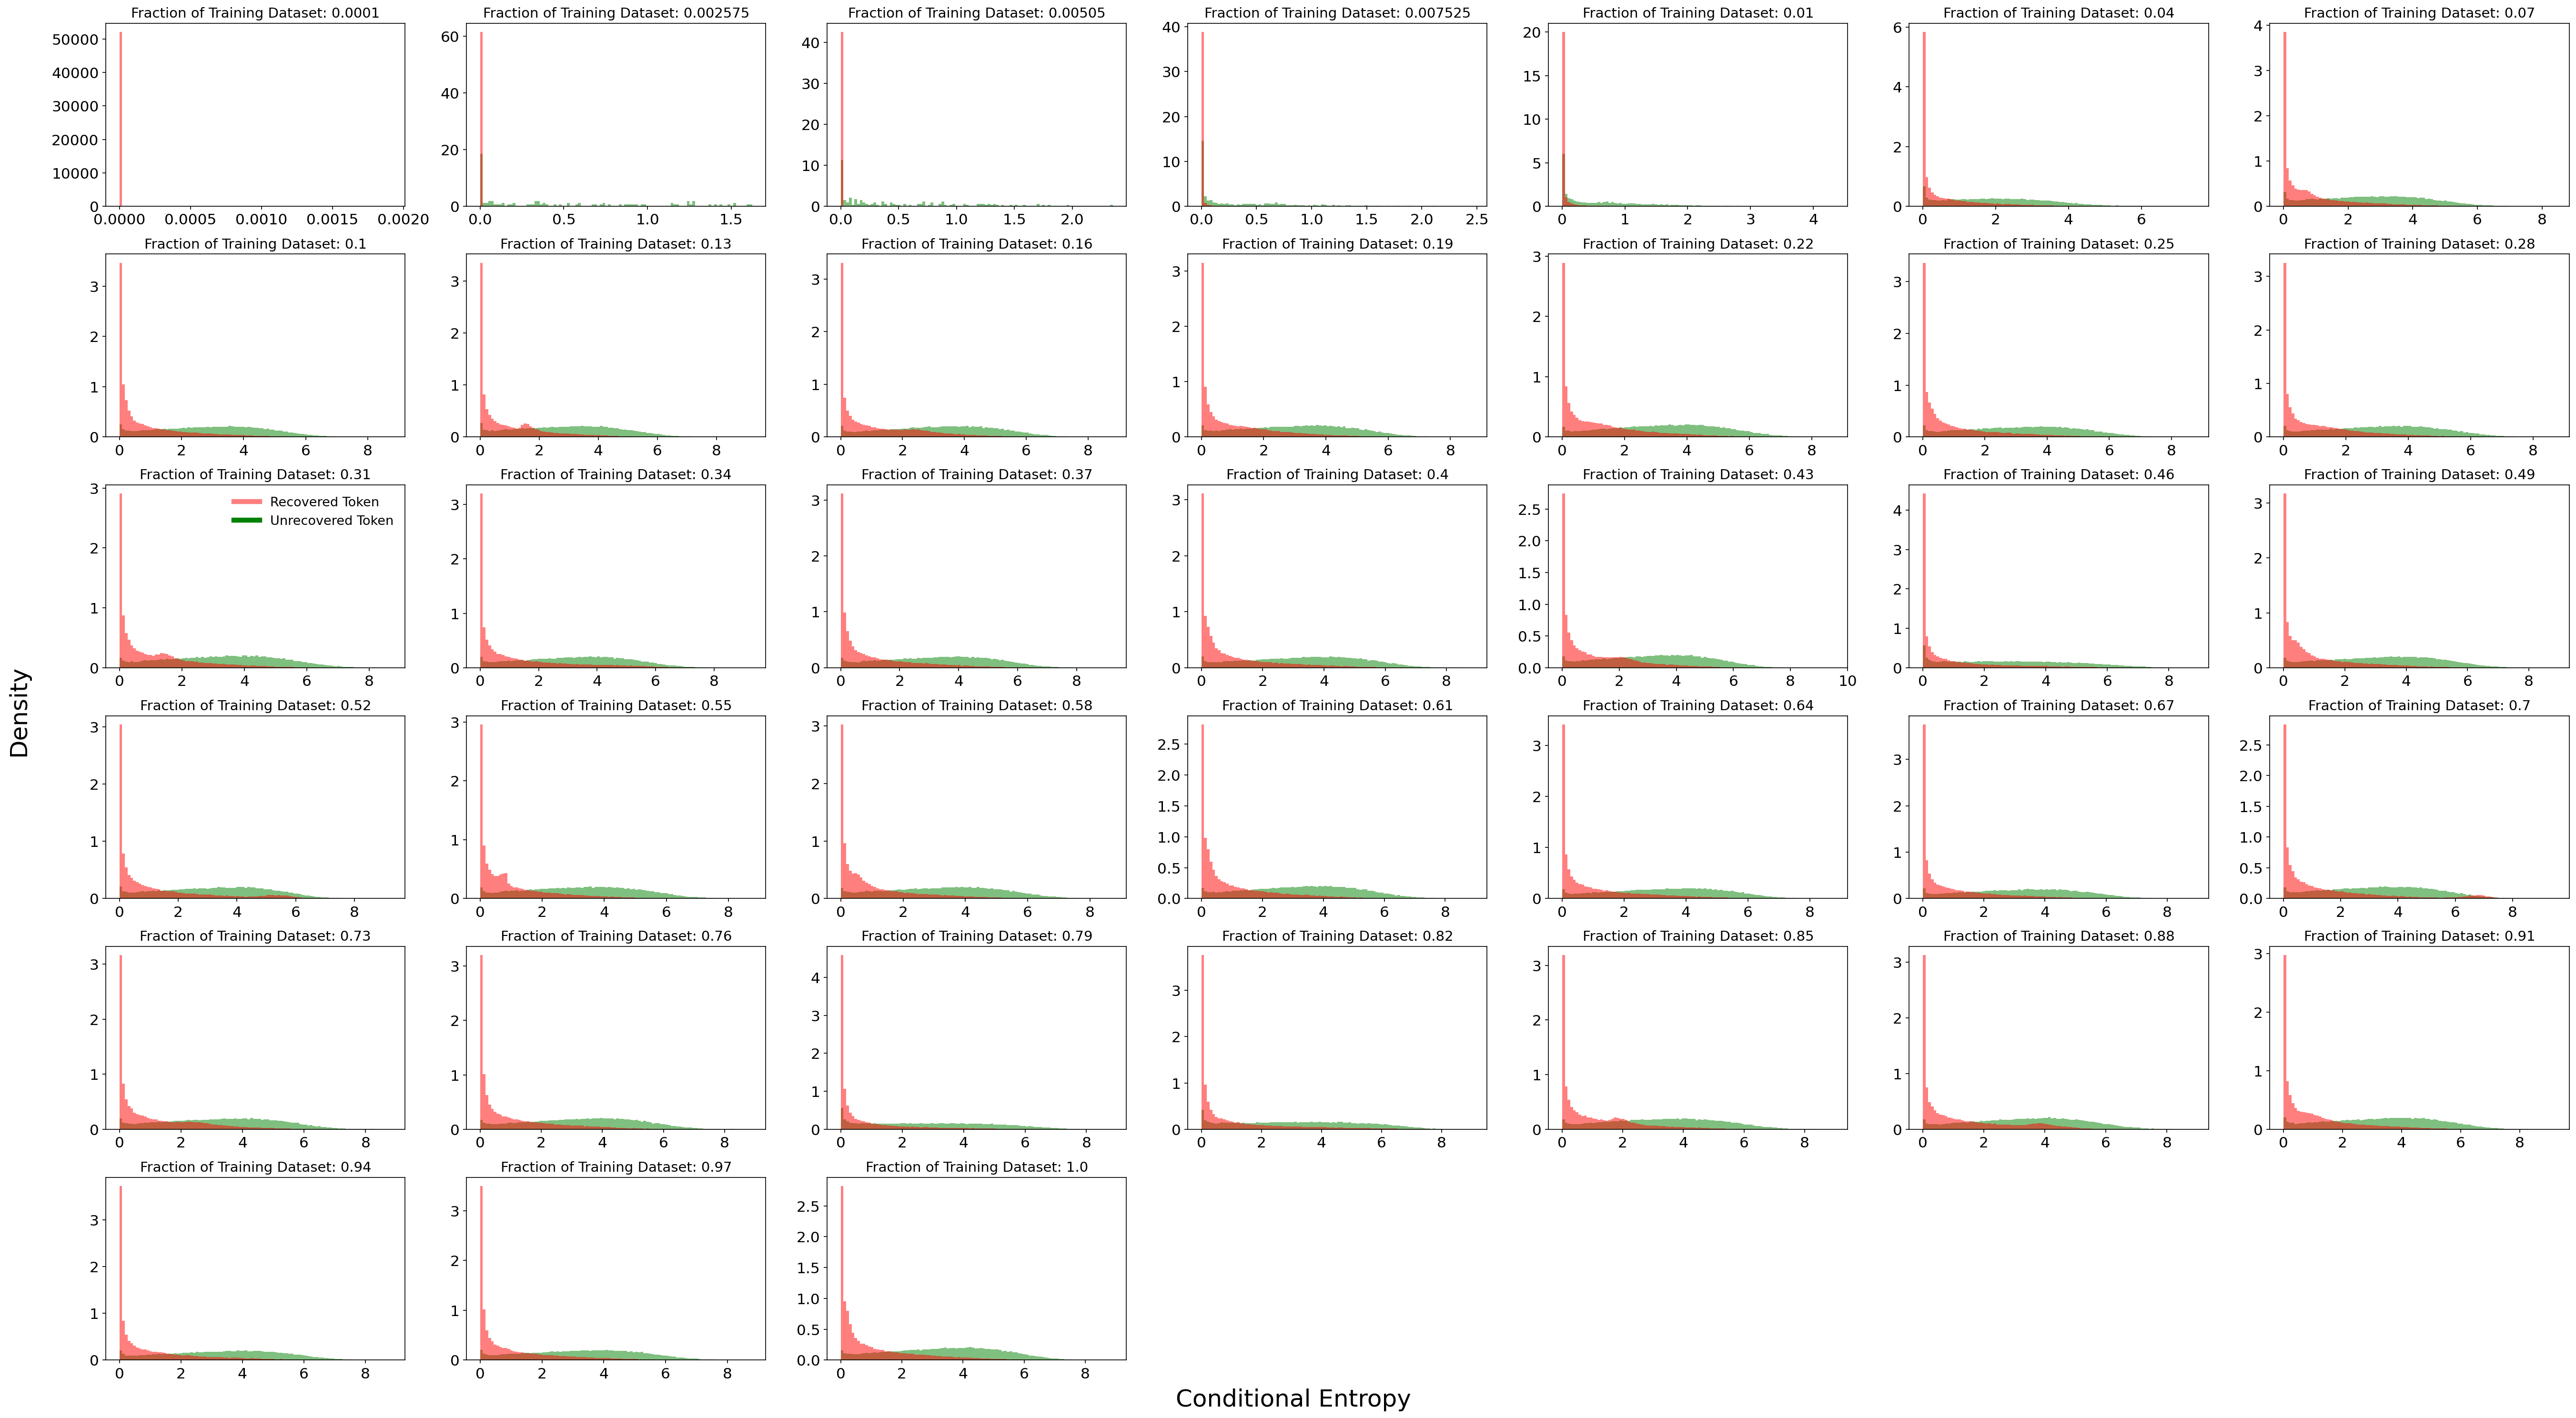

In [8]:
rows, cols = 6, 7

num_bins = 100
fig, axs = plt.subplots(rows, cols, figsize=(36, 20), dpi=150)
flat_axs = axs.flatten()

# Zip safely handles iteration
eidx = 2
data_entries = zip(ent_unstable[eidx], ent_fail[eidx], ent_recovered[eidx])

for idx, (ax, (unstable, fail, recovered)) in enumerate(zip(flat_axs, data_entries)):
    
    # 1. Calculate shared bins based on the min/max of BOTH datasets
    # This ensures the bars align perfectly on the x-axis
    combined_data = np.concatenate([unstable, fail, recovered])
    bins = np.histogram_bin_edges(combined_data, bins=num_bins) 
    
    # 2. Plot Real Data
    # density=True ensures the area under the curve sums to 1
    #ax.hist(unstable, bins=bins, density=False, alpha=0.65, label='Unstable Tokens', color='Blue')    
    ax.hist(fail, bins=bins, density=density, alpha=0.5, label='Unrecovered Tokens', color='Green')
    ax.hist(recovered, bins=bins, density=density, alpha=0.5, label='Recovered Tokens', color='Red')
    
    ax.tick_params(axis='both', labelsize=15)
    
    if idx == 14:
        legend_elements = [
            #Line2D([0], [0], color='Blue', lw=5, alpha=0.5, label='Unstable Token'),
            Line2D([0], [0], color='Red', lw=5, alpha=0.5, label='Recovered Token'),
            Line2D([0], [0], color='Green', lw=5, label='Unrecovered Token'), # Spacer
        ]
        ax.legend(handles=legend_elements, loc='best', frameon=False, fontsize=13)
        #ax.legend(loc='upper right', fontsize=13)
    
    ax.set_title(f"Fraction of Training Dataset: {x_axis[eidx][idx]}", fontsize=14)


# 2. Add the Shared Global Labels
fig.supxlabel("Conditional Entropy", fontsize=24)
fig.supylabel("Count" if not density else 'Density', fontsize=24, x=-0.00001)

# Hide unused plots
for i in range(len(ent_unstable[eidx]), len(flat_axs)):
    flat_axs[i].axis('off')

plt.tight_layout()
plt.show()